In [7]:
import numpy as np
import pandas as pd
import yfinance as yf
from datetime import datetime, timedelta

In [8]:
end_date = datetime.today()
print(end_date)

2026-05-24 20:16:43.716481


In [9]:
start_date = end_date - timedelta(2*365)
print(start_date)

2024-05-24 20:16:43.716481


In [10]:
tickers = ['AAPL', 'META', 'AMZN', 'TSLA']
df = yf.download(tickers, start = start_date, end = end_date, auto_adjust = False, actions = False)

[*********************100%***********************]  4 of 4 completed


In [11]:
df.head()

Price        Adj Close                                           Close  \
Ticker            AAPL        AMZN        META        TSLA        AAPL   
Date                                                                     
2024-05-28  188.358368  182.149994  476.688416  176.750000  189.990005   
2024-05-29  188.655792  182.020004  471.165833  176.190002  190.289993   
2024-05-30  189.647186  179.320007  463.904999  178.789993  191.289993   
2024-05-31  190.598907  176.440002  463.686554  178.080002  192.250000   
2024-06-03  192.363663  178.339996  474.274750  176.289993  194.029999   

Price                                                 High              ...  \
Ticker            AMZN        META        TSLA        AAPL        AMZN  ...   
Date                                                                    ...   
2024-05-28  182.149994  479.920013  176.750000  193.000000  182.240005  ...   
2024-05-29  182.020004  474.359985  176.190002  192.250000  184.080002  ...   
2024-05-30  179.320007  467.049988  178.789993  192.179993  181.339996  ...   
2024-05-31  176.440002  466.829987  178.080002  192.570007  179.210007  ...   
2024-06-03  178.339996  477.489990  176.289993  194.990005  178.699997  ...   

Price              Low                    Open                          \
Ticker            META        TSLA        AAPL        AMZN        META   
Date                                                                     
2024-05-28  474.839996  173.160004  191.509995  179.929993  476.579987   
2024-05-29  473.700012  173.929993  189.610001  181.699997  474.660004   
2024-05-30  464.709991  175.380005  190.759995  181.309998  471.670013   
2024-05-31  454.459991  173.820007  191.440002  178.300003  465.799988   
2024-06-03  468.239990  174.490005  192.899994  177.699997  470.859985   

Price                     Volume                                
Ticker            TSLA      AAPL      AMZN      META      TSLA  
Date                                                            
2024-05-28  176.399994  52280100  29927000  10175800  59736600  
2024-05-29  174.190002  53068000  32009300   9226200  54782600  
2024-05-30  178.580002  49889100  29184700  10719600  77618400  
2024-05-31  178.500000  75158300  58903900  16919800  67314600  
2024-06-03  178.130005  50080500  30786600  11279400  68568900  

[5 rows x 24 columns]

In [12]:
#portfolio weights
w = np.array([0.25,0.25,0.25,0.25])
print(w)

[0.25 0.25 0.25 0.25]


In [13]:
returns = df['Adj Close'].pct_change(fill_method=None).dropna()
returns

Ticker,AAPL,AMZN,META,TSLA
Date,,,,
2024-05-29,0.001579,-0.000714,-0.011585,-0.003168
2024-05-30,0.005255,-0.014834,-0.015410,0.014757
2024-05-31,0.005018,-0.016061,-0.000471,-0.003971
2024-06-03,0.009259,0.010768,0.022835,-0.010052
2024-06-04,0.001649,0.005607,-0.001047,-0.008622
...,...,...,...,...
2026-05-18,-0.007961,0.002726,-0.004917,-0.029012
2026-05-19,0.003794,-0.020841,-0.014071,-0.014342
2026-05-20,0.010971,0.021863,0.004066,0.032541


In [14]:
portfolio_returns = returns.dot(w)
portfolio_returns

Date
2024-05-29   -0.003472
2024-05-30   -0.002558
2024-05-31   -0.003871
2024-06-03    0.008203
2024-06-04   -0.000603
                ...   
2026-05-18   -0.009791
2026-05-19   -0.011365
2026-05-20    0.017360
2026-05-21    0.006833
2026-05-22    0.007214
Length: 498, dtype: float64

<Axes: title={'center': 'Daily Portfolio Returns'}, xlabel='Date'>

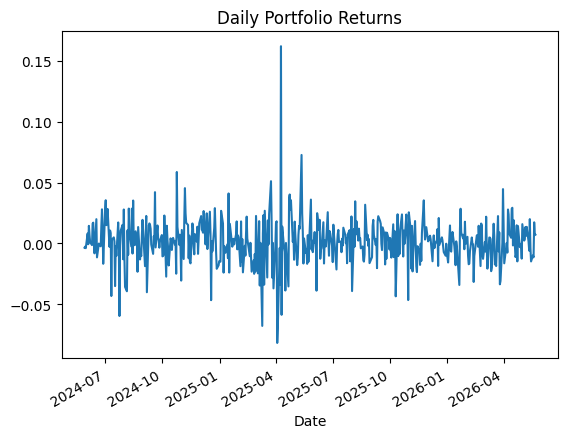

In [16]:
portfolio_returns.plot(fig=(12,6), title="Daily Portfolio Returns")

<Axes: >

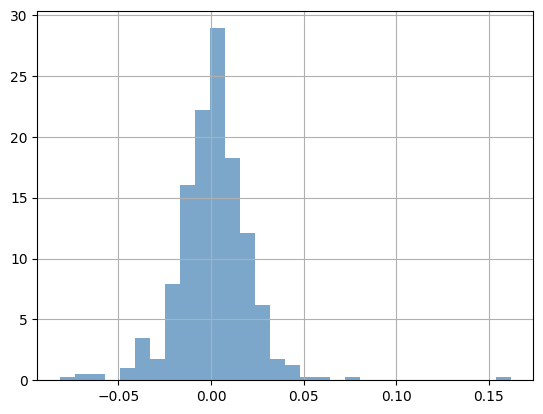

In [17]:
portfolio_returns.hist(bins=30, density=True, alpha=0.7, color='steelblue')

In [20]:
s = returns.cov()
print(s)

Ticker      AAPL      AMZN      META      TSLA
Ticker                                        
AAPL    0.000316  0.000170  0.000168  0.000297
AMZN    0.000170  0.000414  0.000277  0.000366
META    0.000168  0.000277  0.000514  0.000360
TSLA    0.000297  0.000366  0.000360  0.001473


In [31]:
r = returns.corr()
print(r)

Ticker      AAPL      AMZN      META      TSLA
Ticker                                        
AAPL    1.000000  0.468569  0.416324  0.435180
AMZN    0.468569  1.000000  0.599743  0.469194
META    0.416324  0.599743  1.000000  0.414102
TSLA    0.435180  0.469194  0.414102  1.000000


In [25]:
portfolio_variance = np.dot(w.T, np.dot(s,w))
print(portfolio_variance)

0.00037446520280555933


In [26]:
portfolio_volatility = np.sqrt(portfolio_variance)
print(portfolio_volatility)

0.019351103400208458


In [27]:
individual_volatility = returns.std()
print(individual_volatility)

Ticker
AAPL    0.017778
AMZN    0.020351
META    0.022663
TSLA    0.038378
dtype: float64


In [28]:
portfolio_volatility_annualized = portfolio_volatility * np.sqrt(252)
print(portfolio_volatility_annualized)

0.30718924314988794


In [29]:
individual_volatility_annualized = individual_volatility * np.sqrt(252)
print(individual_volatility_annualized)

Ticker
AAPL    0.282212
AMZN    0.323059
META    0.359765
TSLA    0.609226
dtype: float64


Observation:
The portfolio volatility is relatively closer to the volatility of AAPL and AMZN, and visibly lower than the volatility of META and TSLA. This indicates the effects of diversification, where combining the stocks into a portfolio reduces the impact of more volatile assets, which results in the portfolio experiencing smaller overall fluctuations than META and TSLA individually

Correlation and Risk Reduction

Correlation measures how strongly two assets move together. When the correlation between assets is lower, their returns do not move in perfect sync, which helps reduce the overall variance of the portfolio.

This is why diversification works. By combining assets that are not perfectly correlated, the portfolio can experience smaller overall fluctuations than some of the individual stocks on their own.

In this notebook, the correlation values are positive but not extremely high, which means the stocks do not move exactly together. As a result, combining them into a portfolio helps reduce total risk compared with holding only the more volatile individual stocks.